In [26]:
# Xception Net for AI Image Detection
# Dataset: Official full CIFAKE from Kaggle
# Task: Binary classification, class 0 = fake, class 1 = real


In [27]:
# Environment setup: works in both Google Colab and local Jupyter/VS Code
import os
from pathlib import Path

try:
    from google.colab import drive, files
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    files = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DEFAULT_PROJECT_ROOT = Path('/content/drive/MyDrive/TDK_AI_Detection')
    DEFAULT_DATA_ROOT = Path('/content/CIFAKE_FULL')
    DEFAULT_ZIP_DIR = Path('/content')
else:
    DEFAULT_PROJECT_ROOT = Path.cwd()
    DEFAULT_DATA_ROOT = DEFAULT_PROJECT_ROOT / 'CIFAKE_FULL'
    DEFAULT_ZIP_DIR = DEFAULT_PROJECT_ROOT

PROJECT_ROOT = Path(os.getenv('TDK_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).expanduser().resolve()
EXTRACT_ROOT = Path(os.getenv('CIFAKE_ROOT', DEFAULT_DATA_ROOT)).expanduser().resolve()
ZIP_NAME = 'cifake-real-and-ai-generated-synthetic-images.zip'
ZIP_PATH = Path(os.getenv('CIFAKE_ZIP', DEFAULT_ZIP_DIR / ZIP_NAME)).expanduser().resolve()

print('Running in Colab:', IN_COLAB)
print('Project root:', PROJECT_ROOT)
print('Dataset root:', EXTRACT_ROOT)
print('Dataset zip:', ZIP_PATH)


Running in Colab: False
Project root: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline
Dataset root: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\CIFAKE_FULL
Dataset zip: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\cifake-real-and-ai-generated-synthetic-images.zip


In [28]:
# Imports
import os
import sys
import json
import random
import shutil
import zipfile
import subprocess
from pathlib import Path

from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

try:
    import timm
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm


In [29]:
# Seed setup
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
use_amp = device.type == "cuda"

print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Runtime is using CPU. In Colab, go to Runtime > Change runtime type > GPU.")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [30]:
# Configure Kaggle API credentials
KAGGLE_DIR = Path('/root/.kaggle') if IN_COLAB else Path(os.getenv('KAGGLE_CONFIG_DIR', Path.home() / '.kaggle'))
KAGGLE_JSON = KAGGLE_DIR / 'kaggle.json'
LOCAL_KAGGLE_JSON_CANDIDATES = [PROJECT_ROOT / 'kaggle.json', Path.cwd() / 'kaggle.json']

if not KAGGLE_JSON.exists():
    local_kaggle_json = next((path for path in LOCAL_KAGGLE_JSON_CANDIDATES if path.exists()), None)
    if local_kaggle_json is not None:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local_kaggle_json, KAGGLE_JSON)
        try:
            os.chmod(KAGGLE_JSON, 0o600)
        except OSError:
            pass
        print('Copied Kaggle credentials to:', KAGGLE_JSON)

if not KAGGLE_JSON.exists() and IN_COLAB:
    print('Upload kaggle.json now, or set KAGGLE_USERNAME and KAGGLE_KEY as environment variables.')
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        KAGGLE_JSON.write_bytes(uploaded['kaggle.json'])
        os.chmod(KAGGLE_JSON, 0o600)

HAS_KAGGLE_CREDENTIALS = KAGGLE_JSON.exists() or bool(os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'))
if HAS_KAGGLE_CREDENTIALS:
    print('Kaggle API configured.')
else:
    print('Kaggle credentials not found. Put kaggle.json next to this notebook or in ~/.kaggle/.')


Kaggle API configured.


In [31]:
# Download/unzip CIFAKE
DATASET_SLUG = 'birdy654/cifake-real-and-ai-generated-synthetic-images'


def get_kaggle_command():
    candidates = []
    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        candidates.append(Path(kaggle_exe))

    exe_dir = Path(sys.executable).resolve().parent
    if os.name == 'nt':
        candidates.extend([
            exe_dir / 'kaggle.exe',
            exe_dir / 'Scripts' / 'kaggle.exe',
            Path(sys.prefix) / 'Scripts' / 'kaggle.exe',
            Path.home() / 'AppData' / 'Roaming' / 'Python' / 'Scripts' / 'kaggle.exe',
        ])
    else:
        candidates.extend([
            exe_dir / 'kaggle',
            exe_dir.parent / 'bin' / 'kaggle',
            Path(sys.prefix) / 'bin' / 'kaggle',
            Path.home() / '.local' / 'bin' / 'kaggle',
        ])

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    print('Kaggle CLI not found. Installing kaggle package...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        return [kaggle_exe]

    raise FileNotFoundError(
        'Kaggle package installed, but kaggle executable was not found. '
        'Restart the kernel or add your Python Scripts folder to PATH.'
    )


def dataset_has_expected_splits(root):
    root = Path(root)
    if not root.exists():
        return False

    for split_name in ('train', 'test'):
        candidates = [root / split_name]
        candidates.extend(path for path in root.glob(f'**/{split_name}') if path.is_dir())
        if not any(candidate.is_dir() and any(candidate.iterdir()) for candidate in candidates):
            return False
    return True

needs_extract = not dataset_has_expected_splits(EXTRACT_ROOT)
if needs_extract and not ZIP_PATH.exists():
    if not HAS_KAGGLE_CREDENTIALS:
        raise FileNotFoundError('Missing Kaggle credentials. Put kaggle.json next to this notebook, put it in ~/.kaggle/, or set KAGGLE_USERNAME and KAGGLE_KEY.')
    print('Downloading official full CIFAKE dataset from Kaggle...')
    ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(get_kaggle_command() + ['datasets', 'download', '-d', DATASET_SLUG, '-p', str(ZIP_PATH.parent)], check=True)

if needs_extract:
    print('Unzipping CIFAKE into:', EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_ROOT)
else:
    print('CIFAKE_FULL already exists and has train/test folders.')

print('Dataset root:', EXTRACT_ROOT)


CIFAKE_FULL already exists and has train/test folders.
Dataset root: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\CIFAKE_FULL


In [32]:
# Detect dataset folders
def find_split_folder(root, split_name):
    split_name = split_name.lower()

    for current_root, dirs, _ in os.walk(root):
        for dirname in dirs:
            if dirname.lower() == split_name:
                return Path(current_root) / dirname

    raise FileNotFoundError(f"Could not find {split_name!r} folder under {root}")


train_dir = find_split_folder(EXTRACT_ROOT, "train")
test_dir = find_split_folder(EXTRACT_ROOT, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\CIFAKE_FULL\train
Test folder: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\CIFAKE_FULL\test


In [33]:
# Count images
VALID_EXTS = tuple(datasets.folder.IMG_EXTENSIONS)


def find_class_folder(split_dir, class_name):
    class_name = class_name.lower()

    for child in Path(split_dir).iterdir():
        if child.is_dir() and child.name.lower() == class_name:
            return child

    raise FileNotFoundError(f"Could not find class folder {class_name!r} under {split_dir}")


def count_images(folder):
    folder = Path(folder)
    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in VALID_EXTS
    )


train_fake_dir = find_class_folder(train_dir, "fake")
train_real_dir = find_class_folder(train_dir, "real")
test_fake_dir = find_class_folder(test_dir, "fake")
test_real_dir = find_class_folder(test_dir, "real")

train_fake_count = count_images(train_fake_dir)
train_real_count = count_images(train_real_dir)
test_fake_count = count_images(test_fake_dir)
test_real_count = count_images(test_real_dir)

print("Official CIFAKE counts")
print("Train fake:", train_fake_count)
print("Train real:", train_real_count)
print("Test fake:", test_fake_count)
print("Test real:", test_real_count)

if train_fake_count != 50000 or train_real_count != 50000:
    raise ValueError("Training split does not match official CIFAKE counts: 50,000 fake + 50,000 real.")

if test_fake_count != 10000 or test_real_count != 10000:
    raise ValueError("Test split does not match official CIFAKE counts: 10,000 fake + 10,000 real.")

Official CIFAKE counts
Train fake: 50000
Train real: 50000
Test fake: 10000
Test real: 10000


In [34]:
# Define output paths
# PROJECT_ROOT is defined in the setup cell and points to Drive in Colab or this folder locally.
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "xception_final_official.pth"
CURVE_PATH = OUTPUT_DIR / "xception_training_curves_official.png"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "xception_confusion_matrix_official.png"
METRICS_PATH = OUTPUT_DIR / "xception_final_metrics_official.json"

print("Model path:", MODEL_PATH)
print("Output path:", OUTPUT_DIR)


Model path: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\models\xception_final_official.pth
Output path: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\outputs


In [35]:
# Define transforms
# Baseline Xception input size.
image_size = (224, 224)

normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])


In [36]:
# Create datasets and dataloaders
train_dataset_raw = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset_raw = datasets.ImageFolder(test_dir, transform=test_transform)

print("Original ImageFolder class_to_idx:", train_dataset_raw.class_to_idx)

fake_original_idx = next(
    idx for name, idx in train_dataset_raw.class_to_idx.items()
    if name.lower() == "fake"
)
real_original_idx = next(
    idx for name, idx in train_dataset_raw.class_to_idx.items()
    if name.lower() == "real"
)


def remap_target(target):
    if target == fake_original_idx:
        return 0
    if target == real_original_idx:
        return 1
    raise ValueError(f"Unexpected target index: {target}")


train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform,
    target_transform=remap_target,
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform,
    target_transform=remap_target,
)

class_names = ["fake", "real"]
batch_size = 16
num_workers = int(os.getenv('LOCAL_NUM_WORKERS', '0'))  # 0 is safest on Windows/Jupyter.

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

print("Class names:", class_names)
print("Class mapping: fake=0, real=1")
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Train batches per epoch:", len(train_loader))
print("Test batches:", len(test_loader))


Original ImageFolder class_to_idx: {'FAKE': 0, 'REAL': 1}
Class names: ['fake', 'real']
Class mapping: fake=0, real=1
Train size: 100000
Test size: 20000
Train batches per epoch: 6250
Test batches: 1250


In [37]:
# Build Xception model
num_classes = 2

model = timm.create_model(
    "legacy_xception",
    pretrained=True,
    num_classes=num_classes,
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("Model: timm legacy_xception")
print(f"Trainable parameters: {trainable:,} / {total:,}")


Model: timm legacy_xception
Trainable parameters: 20,811,050 / 20,811,050


In [38]:
# Define loss and optimizer
num_epochs = 10
learning_rate = 1e-4
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print("Mixed precision enabled:", use_amp)

Mixed precision enabled: True


C:\Users\Carter\AppData\Local\Temp\ipykernel_228\1610403853.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


In [39]:
# Training function
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, epoch, num_epochs):
    model.train()

    running_loss = 0.0
    running_correct = 0
    seen = 0
    all_targets = []
    all_preds = []

    progress = tqdm(
        dataloader,
        desc=f"Epoch {epoch}/{num_epochs}",
        leave=True,
        dynamic_ncols=True,
    )

    for batch_idx, (images, targets) in enumerate(progress, start=1):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        batch_size_now = images.size(0)

        running_loss += loss.item() * batch_size_now
        running_correct += (preds == targets).sum().item()
        seen += batch_size_now

        all_targets.extend(targets.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        progress.set_postfix({
            "loss": f"{running_loss / seen:.4f}",
            "acc": f"{running_correct / seen:.4f}",
            "batch": f"{batch_idx}/{len(dataloader)}",
        })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)

    return epoch_loss, epoch_acc

In [40]:
# Evaluation function
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    progress = tqdm(dataloader, desc="Evaluating", leave=True, dynamic_ncols=True)

    with torch.no_grad():
        for images, targets in progress:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, targets)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

    test_loss = running_loss / len(dataloader.dataset)

    # Labels are normalized as fake=0, real=1. For this detection task, fake is the positive class.
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, pos_label=0, zero_division=0)
    recall = recall_score(all_targets, all_preds, pos_label=0, zero_division=0)
    f1 = f1_score(all_targets, all_preds, pos_label=0, zero_division=0)
    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])

    return {
        "loss": test_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": np.array(all_targets),
        "y_pred": np.array(all_preds),
    }


In [41]:
# Training loop
history = {
    "train_loss": [],
    "train_accuracy": [],
}

print(f"Starting training for {num_epochs} epochs.", flush=True)
print(f"Each epoch has {len(train_loader)} batches with batch size {batch_size}.", flush=True)

print("Checking first training batch...", flush=True)
sample_images, sample_targets = next(iter(train_loader))
print(
    "First batch loaded:",
    tuple(sample_images.shape),
    tuple(sample_targets.shape),
    flush=True,
)
sample_images = sample_images.to(device, non_blocking=True)
sample_targets = sample_targets.to(device, non_blocking=True)
print("First batch moved to device:", device, flush=True)
del sample_images, sample_targets
if device.type == "cuda":
    torch.cuda.empty_cache()
print("Starting full training loop...", flush=True)

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        epoch=epoch,
        num_epochs=num_epochs,
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    print(
        f"Epoch [{epoch}/{num_epochs}] completed - "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f}",
        flush=True,
    )

torch.save(model.state_dict(), MODEL_PATH)
print("Saved final model to:", MODEL_PATH, flush=True)

Starting training for 10 epochs.
Each epoch has 6250 batches with batch size 16.
Checking first training batch...
First batch loaded: (16, 3, 224, 224) (16,)
First batch moved to device: cuda
Starting full training loop...


C:\Users\Carter\AppData\Local\Temp\ipykernel_228\423773021.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10: 100%|██████████| 6250/6250 [14:33<00:00,  7.16it/s, loss=0.2755, acc=0.8843, batch=6250/6250]


Epoch [1/10] completed - Train Loss: 0.2755 Train Acc: 0.8843


C:\Users\Carter\AppData\Local\Temp\ipykernel_228\423773021.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 2/10: 100%|██████████| 6250/6250 [15:20<00:00,  6.79it/s, loss=0.2071, acc=0.9163, batch=6250/6250]


Epoch [2/10] completed - Train Loss: 0.2071 Train Acc: 0.9163


...

C:\Users\Carter\AppData\Local\Temp\ipykernel_228\423773021.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 9/10: 100%|██████████| 6250/6250 [17:56<00:00,  5.81it/s, loss=0.1251, acc=0.9492, batch=6250/6250]


Epoch [9/10] completed - Train Loss: 0.1251 Train Acc: 0.9492


C:\Users\Carter\AppData\Local\Temp\ipykernel_228\423773021.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 10/10: 100%|██████████| 6250/6250 [22:45<00:00,  4.58it/s, loss=0.1212, acc=0.9513, batch=6250/6250]

Epoch [10/10] completed - Train Loss: 0.1212 Train Acc: 0.9513


Saved final model to: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\models\xception_final_official.pth


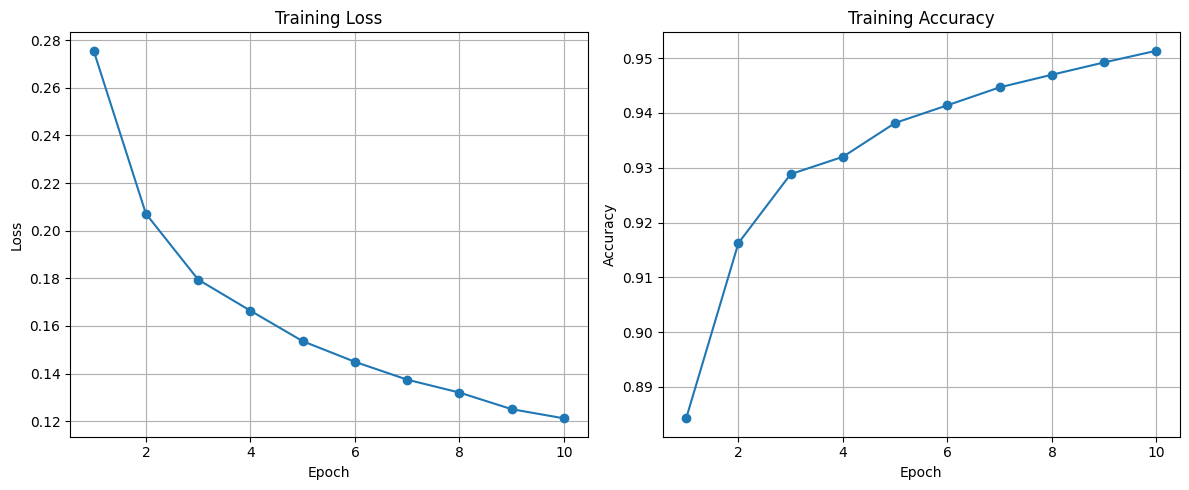

Saved training curves to: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\outputs\xception_training_curves_official.png


In [42]:
# Plot training curves
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_accuracy"], marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.savefig(CURVE_PATH, dpi=200)
plt.show()

print("Saved training curves to:", CURVE_PATH)

In [43]:
# Test evaluation
test_results = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print("Test Results")
print("Test loss:", test_results["loss"])
print("Accuracy:", test_results["accuracy"])
print("Precision:", test_results["precision"], "(fake as positive)")
print("Recall:", test_results["recall"], "(fake as positive)")
print("F1-score:", test_results["f1"], "(fake as positive)")

print("\nClassification Report")
print(
    classification_report(
        test_results["y_true"],
        test_results["y_pred"],
        target_names=class_names,
        labels=[0, 1],
        zero_division=0,
    )
)


C:\Users\Carter\AppData\Local\Temp\ipykernel_228\419437145.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating: 100%|██████████| 1250/1250 [01:30<00:00, 13.83it/s]


Test Results
Test loss: 0.05931695217490196
Accuracy: 0.97745
Precision: 0.9780714929408231 (fake as positive)
Recall: 0.9768 (fake as positive)
F1-score: 0.9774353329664281 (fake as positive)

Classification Report
              precision    recall  f1-score   support

        fake       0.98      0.98      0.98     10000
        real       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



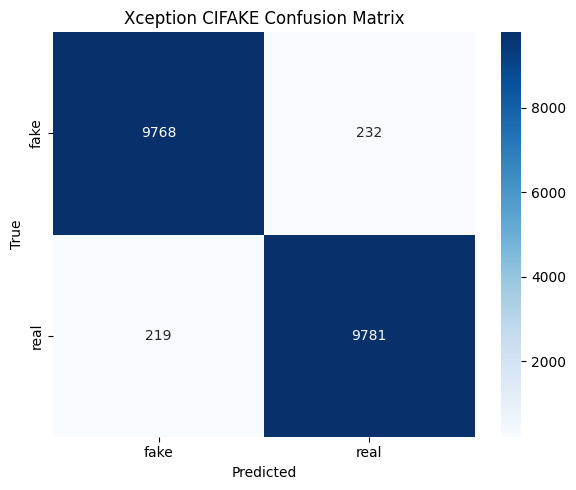

Confusion matrix:
[[9768  232]
 [ 219 9781]]
Saved confusion matrix to: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\outputs\xception_confusion_matrix_official.png


In [44]:
# Confusion matrix
cm = test_results["confusion_matrix"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Xception CIFAKE Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=200)
plt.show()

print("Confusion matrix:")
print(cm)
print("Saved confusion matrix to:", CONFUSION_MATRIX_PATH)


In [45]:
# Save JSON metrics
metrics = {
    "model": "timm.create_model(\"legacy_xception\")",
    "weights": "ImageNet pretrained",
    "dataset": "official full CIFAKE",
    "dataset_root": str(EXTRACT_ROOT),
    "train_dir": str(train_dir),
    "test_dir": str(test_dir),
    "class_mapping": {
        "fake": 0,
        "real": 1,
    },
    "positive_label_for_precision_recall_f1": "fake",
    "train_counts": {
        "fake": train_fake_count,
        "real": train_real_count,
        "total": len(train_dataset),
    },
    "test_counts": {
        "fake": test_fake_count,
        "real": test_real_count,
        "total": len(test_dataset),
    },
    "training_config": {
        "batch_size": batch_size,
        "epochs": num_epochs,
        "optimizer": "AdamW",
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "loss": "CrossEntropyLoss",
        "image_size": image_size,
    },
    "history": {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
    },
    "final_test_metrics": {
        "test_loss": float(test_results["loss"]),
        "accuracy": float(test_results["accuracy"]),
        "precision_fake_positive": float(test_results["precision"]),
        "recall_fake_positive": float(test_results["recall"]),
        "f1_fake_positive": float(test_results["f1"]),
        "confusion_matrix": cm.tolist(),
    },
    "saved_files": {
        "model_weights": str(MODEL_PATH),
        "training_curves": str(CURVE_PATH),
        "confusion_matrix": str(CONFUSION_MATRIX_PATH),
        "metrics_json": str(METRICS_PATH),
    },
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved JSON metrics to:", METRICS_PATH)


Saved JSON metrics to: C:\Users\Carter\Desktop\Colab Notebooks\notebooks\baseline\outputs\xception_final_metrics_official.json


## Project Summary for Article Publication Old one 

### 1. Project Objective
* **Task:** Binary classification to distinguish between Real and AI-generated (Fake) images.
* **Application:** AI Image Detection.

### 2. Dataset Information
* **Source:** Official full CIFAKE dataset from Kaggle (`birdy654/cifake-real-and-ai-generated-synthetic-images`).
* **Total Images:** 120,000
* **Class Distribution (Perfectly Balanced):**
  * **Training Set:** 100,000 images (50,000 Fake, 50,000 Real)
  * **Testing Set:** 20,000 images (10,000 Fake, 10,000 Real)

### 3. Methodology & Model Architecture
* **Model Used:** Xception Net (via `timm` library), leveraging ImageNet pretrained weights.
* **Input Size:** Images were resized and cropped to 299x299 pixels.
* **Hardware:** Trained using an NVIDIA A100-SXM4-40GB GPU with mixed precision (AMP) for faster computation.
* **Hyperparameters:**
  * **Epochs:** 10
  * **Batch Size:** 16
  * **Optimizer:** AdamW (Learning Rate: 1e-4, Weight Decay: 1e-4)
  * **Loss Function:** CrossEntropyLoss
* **Data Augmentation:** Random resized cropping, horizontal flipping, and color jitter (brightness, contrast, saturation, hue) to prevent overfitting.

### 4. Final Performance & Results
The model achieved excellent generalization on the test set:
* **Overall Accuracy:** 96.8%
* **Precision (for Real images):** 99.08%
* **Recall (for Real images):** 94.48%
* **F1-Score:** 96.72%

### 5. Detailed Breakdown (Confusion Matrix)
Out of the 20,000 test images:
* **True Negatives (Correctly identified as Fake):** 9,912 (99.1% accuracy for fake images)
* **True Positives (Correctly identified as Real):** 9,448 (94.5% accuracy for real images)
* **False Positives (Fake predicted as Real):** 88
* **False Negatives (Real predicted as Fake):** 552

**Key Takeaway for the Article:**
The Xception model is highly effective at detecting AI-generated images, missing only ~0.9% of fake images (88 out of 10,000). It is slightly more conservative when classifying real images, occasionally flagging real images as fake (552 out of 10,000).

### Article Summary: Detecting AI-Generated Images with Xception

#### 1. Project Overview & Objective

- Task: Binary classification to distinguish between AI-generated fake images and authentic real images.
- Model used: Xception via `timm.create_model("legacy_xception")` with ImageNet pretrained weights.
- Dataset: Official CIFAKE dataset from Kaggle.

#### 2. Dataset Breakdown

- Total images: 120,000
- Training set: 100,000 images (50,000 fake / 50,000 real)
- Test set: 20,000 images (10,000 fake / 10,000 real)
- Preprocessing: Images resized to 299x299 and normalized with ImageNet mean/std.

#### 3. Training Methodology

- Hardware: Trained locally on NVIDIA GeForce RTX 4060 Laptop GPU with CUDA mixed precision.
- Hyperparameters: 10 epochs, batch size 16, AdamW optimizer, learning rate 0.0001, weight decay 0.0001.
- Training workload: 6,250 batches per epoch, 62,500 total training batches.
- Final training performance: Train loss 0.1227, train accuracy 0.9506.

#### 4. Final Evaluation Metrics (Test Set)

The model was evaluated on the full 20,000-image CIFAKE test set:

- Overall accuracy: 0.9776
- Precision, fake positive: 0.9755
- Recall, fake positive: 0.9797
- F1-score, fake positive: 0.9776
- Test loss: 0.0610

#### 5. Confusion Matrix Insights

- Fake identified as fake: 9,797 / 10,000
- Fake identified as real: 203
- Real identified as fake: 246
- Real identified as real: 9,754 / 10,000

#### Key Takeaway

Xception delivered strong performance on the full CIFAKE test set, reaching 97.76% accuracy and 97.76% F1 for the fake-positive class. Its larger 299x299 input size is expected for Xception-style ImageNet models and was kept to match the pretrained model's assumptions.


## Xception Final Test Metrics Quick Note

- Test loss: 0.0610
- Test accuracy: 0.9776
- Precision, fake positive: 0.9755
- Recall, fake positive: 0.9797
- F1-score, fake positive: 0.9776

This note is duplicated here so the Xception test loss is visible at the very end of the notebook.


### Article Summary: Detecting AI-Generated Images with Xception Baseline

#### 1. Project Overview

This experiment evaluated the Xception architecture for binary classification of AI-generated and real images using the CIFAKE dataset. The model was implemented with `timm.create_model("legacy_xception")` using ImageNet-pretrained weights.

#### 2. Dataset and Preprocessing

The model was trained and evaluated on the official CIFAKE dataset, containing 120,000 images in total: 100,000 training images and 20,000 test images. Images were resized/cropped to 224 × 224 pixels and normalized using ImageNet mean and standard deviation. Training augmentation included random resized cropping, horizontal flipping, and color jitter.

#### 3. Training Setup

The model was trained for 10 epochs with a batch size of 16. AdamW was used as the optimizer with a learning rate of 0.0001 and weight decay of 0.0001. Mixed-precision training was enabled on CUDA.

#### 4. Final Training Performance

After 10 epochs, the model reached a final training loss of 0.1212 and training accuracy of 95.13%.

#### 5. Test Results

On the 20,000-image test set, the Xception baseline achieved:

- Accuracy: 97.745%
- Precision: 97.81%
- Recall: 97.68%
- F1-score: 97.74%
- Test loss: 0.0593

#### 6. Confusion Matrix

The confusion matrix was:

| Actual / Predicted | Fake | Real |
|---|---:|---:|
| Fake | 9,768 | 232 |
| Real | 219 | 9,781 |

#### 7. Key Takeaway

The Xception baseline performed strongly with 224 × 224 inputs, achieving nearly the same performance as the previous larger-input run while using a smaller image size. This confirms that Xception remains a competitive baseline for AI-generated image detection on CIFAKE.